In [21]:
import json
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, chisquare
from statsmodels.stats.proportion import confint_proportions_2indep, proportion_confint

sys.path.insert(0, str(pathlib.Path.cwd().parents[0]))
import helpers.character_colours as character_colours

%matplotlib inline

In [2]:
repository_path = pathlib.Path.cwd().parents[2]
simulations_path = repository_path / "data" / "simulations"
hypothesis_results_path = repository_path / "data" / "hypothesis_results"

In [3]:
simulation_games_data = pd.read_csv(simulations_path / "games.csv")
simulation_characters_data = pd.read_csv(simulations_path / "game_characters.csv")

# Hypothesis 2 - Duplication effect at 7 and 8 players

## 2.1. Question and pre-registered test

**Question.** At 7 and 8 players, does the team's win probability depend on which non-Craftsman role(s) get duplicated to fill the extra seats?

- **$H_0$:** within each player count (7 and 8), the team win rate is the same regardless of which non-Craftsman role(s) are duplicated.
- **$H_1$:** within at least one player count, the team win rate differs across duplication buckets.

**Why this matters.** The rules force every game to use all six characters at 6 players. At 7 and 8 players, the rulebook adds one or two extra seats and fills them by duplicating non-Craftsman roles **at random**. That randomness is part of the play experience - groups never know in advance which roles they will see twice - but it is also a hidden lever on balance: if duplicating one role (or one specific pair of roles) systematically pushes the win rate up or down, the player-count effect we measured in Hypothesis 1 is partly an artefact of the duplication mechanic rather than of group size itself.

**Test.** Two independent chi-square tests of independence, one per player count, on the contingency table (bucket x win / loss). Per-bucket 95% Wilson confidence intervals on the win rate, plus 95% CIs on each pairwise difference of proportions. Significance level $\alpha = 0.05$. Both chi-square p-values enter the Holm-Bonferroni family in the main notebook under the single label **Hypothesis 2**, with the smaller of the two reported as the H2 representative.

The bucket definition is asymmetric across the two player counts:

- **7 players:** one non-Craftsman role is duplicated, so the bucket is just that role. Five buckets total (Builder, Cook, Fire Starter, Gatherer, Sailor).
- **8 players:** two non-Craftsman roles are duplicated, so the bucket is the **unordered pair** of those two roles (e.g. `BUILDER|GATHERER`). At most $\binom{5}{2} = 10$ buckets if the two duplicated roles are always distinct.

## 2.2. Recovering the duplicated role(s)

The simulation export does not store the duplicated role directly. It does store one row per (game, character) pair in `game_characters.csv`, so the duplicates fall out of a `groupby` over (`game_id`, `character`) followed by a `count > 1` filter.

- A 6-player game has 6 distinct rows and **zero** survivors.
- A 7-player game has 7 rows where one character appears twice; the filter returns **one** row.
- An 8-player game has 8 rows where two characters appear twice; the filter returns **two** rows.

The chain below builds an `extras_per_game` dataframe with one row per game and three columns: `first_extra` (always populated for 7- and 8-player games), `second_extra` (populated only for 8-player games), and `extra_pair` (the pipe-joined unordered pair, used as the 8-player bucket key).

In [4]:
extras_per_game = (
    simulation_characters_data
    .groupby(["game_id", "character"])
    .size()
    .reset_index(name = "count")
    .query("count > 1")
    .groupby("game_id")["character"]
    .apply(lambda characters: sorted(characters.tolist()))
    .apply(lambda characters: pd.Series({
        "first_extra": characters[0] if len(characters) > 0 else None,
        "second_extra": characters[1] if len(characters) > 1 else None,
        "extra_pair": "|".join(characters) if len(characters) > 0 else None,
    }))
    .reset_index()
)

extras_per_game.head()

,game_id,first_extra,second_extra,extra_pair
0,000c399286410544,BUILDER,NaN,BUILDER
1,0018734aa0290482,BUILDER,NaN,BUILDER
2,001bd48c2f2538fc,BUILDER,GATHERER,BUILDER|GATHERER
3,001d9bf4e17ffaa5,COOK,NaN,COOK
4,00204ebbb9c2eb91,BUILDER,NaN,BUILDER


In [5]:
extras_per_game_data = extras_per_game.set_index("game_id").join(
    simulation_games_data.set_index("game_id"),
    how = "inner",
)

extras_per_game_data.head()

,first_extra,second_extra,extra_pair,seed,player_count,outcome,rounds_played,boat_parts_built,boat_parts_required,volcano_cards_remaining,mission_failures_any_extra
game_id,,,,,,,,,,,
000c399286410544,BUILDER,NaN,BUILDER,20263512,7,win,18,4,4,3,0
0018734aa0290482,BUILDER,NaN,BUILDER,20262617,7,win,16,4,4,6,0
001bd48c2f2538fc,BUILDER,GATHERER,BUILDER|GATHERER,20261908,8,win,17,5,5,3,0
001d9bf4e17ffaa5,COOK,NaN,COOK,20264084,7,win,18,4,4,5,1
00204ebbb9c2eb91,BUILDER,NaN,BUILDER,20261347,7,loss,20,3,4,0,0


## 2.3. Sanity checks

Before running any test, confirm three things about the data:

1. Every 7-player game has exactly **one** duplicated role (`second_extra` is null).
2. Every 8-player game has exactly **two** duplicated roles (`second_extra` is non-null).
3. Every bucket has enough games for the chi-square approximation to be valid - Cochran's rule of thumb asks for an expected count of at least 5 in every cell; with the observed win rates around 0.5 this is essentially "at least 10 games per bucket".

In [6]:
seven_player_extras = extras_per_game_data[extras_per_game_data["player_count"] == 7]
eight_player_extras = extras_per_game_data[extras_per_game_data["player_count"] == 8]

assert seven_player_extras["second_extra"].isna().all(), "7-player game with two duplicates"
assert eight_player_extras["second_extra"].notna().all(), "8-player game with one duplicate"

print(f"7-player games: {len(seven_player_extras)}")
print(f"8-player games: {len(eight_player_extras)}")

7-player games: 4000
8-player games: 4000


In [7]:
bucket_size_7 = seven_player_extras["first_extra"].value_counts().sort_index()
print("Games per bucket (7 players, single role):")
print(bucket_size_7.to_string())

Games per bucket (7 players, single role):
first_extra
BUILDER         806
COOK            829
FIRE_STARTER    816
GATHERER        724
SAILOR          825


In [8]:
bucket_size_8 = eight_player_extras["extra_pair"].value_counts().sort_index()
print("Games per bucket (8 players, unordered pair):")
print(bucket_size_8.to_string())
print(f"\nTotal pair buckets observed: {len(bucket_size_8)}")

Games per bucket (8 players, unordered pair):
extra_pair
BUILDER|COOK             410
BUILDER|FIRE_STARTER     396
BUILDER|GATHERER         419
BUILDER|SAILOR           425
COOK|FIRE_STARTER        388
COOK|GATHERER            389
COOK|SAILOR              427
FIRE_STARTER|GATHERER    379
FIRE_STARTER|SAILOR      399
GATHERER|SAILOR          368

Total pair buckets observed: 10


## 2.4. Seven-player branch

The five buckets at 7 players are the five non-Craftsman roles. The contingency table is `5 x 2` (role x outcome).

In [9]:
contingency_7 = pd.crosstab(
    seven_player_extras["first_extra"],
    seven_player_extras["outcome"],
).reindex(columns = ["loss", "win"], fill_value = 0)

contingency_7

outcome,loss,win
first_extra,,
BUILDER,367,439
COOK,442,387
FIRE_STARTER,442,374
GATHERER,386,338
SAILOR,447,378


In [10]:
win_rate_7 = contingency_7["win"] / contingency_7.sum(axis = 1)

ci_7 = pd.DataFrame(
    [
        proportion_confint(contingency_7.loc[role, "win"], contingency_7.loc[role].sum(), method = "wilson")
        for role in contingency_7.index
    ],
    index = contingency_7.index,
    columns = ["ci_lower", "ci_upper"],
)

summary_7 = pd.concat([contingency_7, win_rate_7.rename("win_rate"), ci_7], axis = 1)
summary_7

,loss,win,win_rate,ci_lower,ci_upper
first_extra,,,,,
BUILDER,367,439,0.544665,0.510154,0.578753
COOK,442,387,0.466828,0.433097,0.500864
FIRE_STARTER,442,374,0.458333,0.424421,0.492636
GATHERER,386,338,0.466851,0.430781,0.503271
SAILOR,447,378,0.458182,0.424455,0.492296


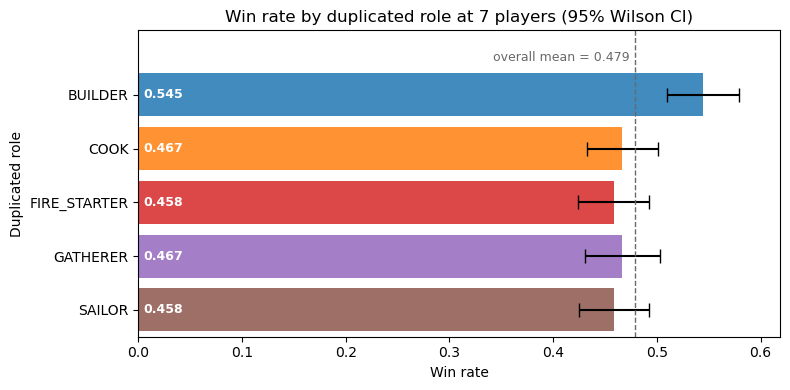

In [31]:
positions = np.arange(len(summary_7))
errors_lower = summary_7["win_rate"].values - summary_7["ci_lower"].values
errors_upper = summary_7["ci_upper"].values - summary_7["win_rate"].values
overall_win_rate_7 = contingency_7["win"].sum() / contingency_7.sum().sum()
bar_colours = [character_colours.CHARACTER_COLOURS[role] for role in summary_7.index]

plt.figure(figsize = (8, 4))

plt.barh(positions, summary_7["win_rate"].values, color = bar_colours, alpha = 0.85)

plt.errorbar(summary_7["win_rate"].values, positions, xerr = [errors_lower, errors_upper],
             fmt = "none", color = "black", capsize = 5)

plt.axvline(overall_win_rate_7, color = "dimgray", linestyle = "--", linewidth = 1)
plt.text(overall_win_rate_7 - 0.005, -0.7, f"overall mean = {overall_win_rate_7:.3f}",
         va = "center", ha = "right", fontsize = 9, color = "dimgray")

plt.yticks(positions, summary_7.index)
plt.xlabel("Win rate")
plt.ylabel("Duplicated role")
plt.xlim(0, summary_7["ci_upper"].max() + 0.04)
plt.ylim(-1.2, len(summary_7) - 0.5)
plt.title("Win rate by duplicated role at 7 players (95% Wilson CI)")

for i, win_rate in enumerate(summary_7["win_rate"].values):
    plt.text(0.005, i, f"{win_rate:.3f}", va = "center", ha = "left",
             color = "white", fontweight = "bold", fontsize = 9)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

**Chi-square test of independence** on the 5 x 2 table. The two-way form (`chi2_contingency`) is the right tool here because both the bucket and the outcome are categorical; the one-way `chisquare` used in Hypothesis 1 only applied because the three player-count groups had equal sample size by design.

In [12]:
chi2_stat_7, p_value_7, dof_7, expected_7 = chi2_contingency(contingency_7.values)

print(f"chi-square statistic:  {chi2_stat_7:.4f}")
print(f"degrees of freedom:    {dof_7}")
print(f"p-value:               {p_value_7:.4e}")
print(f"min expected count:    {expected_7.min():.1f}")

chi-square statistic:  17.6758
degrees of freedom:    4
p-value:               1.4277e-03
min expected count:    346.8


**Pairwise 95% CIs on the difference in win rate** between every pair of duplicated-role buckets. For each pair the table reports the observed difference in win rate and the 95% confidence interval on that difference, computed with the Newcombe hybrid-score interval for the difference of two independent proportions.

The `excludes_zero` column flags whether the CI lies entirely above or entirely below zero. When that is the case, "the two buckets have the same win rate" is outside the 95% CI and can be rejected at the 5% level - so we have evidence the two buckets differ. When the CI contains zero, no difference is plausible and the comparison is inconclusive.

In [13]:
def pairwise_diff_table(contingency):
    rows = []
    labels = list(contingency.index)
    for i, label_a in enumerate(labels):
        wins_a = contingency.loc[label_a, "win"]
        total_a = contingency.loc[label_a].sum()
        rate_a = wins_a / total_a
        for label_b in labels[i + 1:]:
            wins_b = contingency.loc[label_b, "win"]
            total_b = contingency.loc[label_b].sum()
            rate_b = wins_b / total_b
            ci_lower, ci_upper = confint_proportions_2indep(
                count1 = wins_a,
                nobs1 = total_a,
                count2 = wins_b,
                nobs2 = total_b,
                method = "newcomb",
            )
            rows.append({
                "bucket_a": label_a,
                "bucket_b": label_b,
                "diff": rate_a - rate_b,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "excludes_zero": (ci_lower > 0) or (ci_upper < 0),
            })
    return pd.DataFrame(rows)


pairwise_7 = pairwise_diff_table(contingency_7)
pairwise_7

,bucket_a,bucket_b,diff,ci_lower,ci_upper,excludes_zero
0,BUILDER,COOK,0.077838,0.029366,0.125793,True
1,BUILDER,FIRE_STARTER,0.086332,0.037673,0.134415,True
2,BUILDER,GATHERER,0.077814,0.027640,0.127443,True
3,BUILDER,SAILOR,0.086483,0.037957,0.134436,True
4,COOK,FIRE_STARTER,0.008494,-0.039614,0.056541,False
5,COOK,GATHERER,-0.000023,-0.049663,0.049570,False
6,COOK,SAILOR,0.008646,-0.039329,0.056562,False
7,FIRE_STARTER,GATHERER,-0.008517,-0.058281,0.041259,False
8,FIRE_STARTER,SAILOR,0.000152,-0.047951,0.048257,False
9,GATHERER,SAILOR,0.008669,-0.040978,0.058307,False


**Observation (7-player branch).** The chi-square rejects $H_0$ at 7 players ($p = 1.4 \times 10^{-3}$): the five duplicated-role buckets do not share a common win rate. The pairwise CIs localise the source: every BUILDER-vs-other comparison has a difference CI strictly above zero, while no non-Builder pair shows a significant difference. So at 7 players the duplication effect is essentially a *Builder effect* - duplicating Builder lifts the win rate by 7-9 percentage points over duplicating any other role; the four non-Builder roles are statistically interchangeable.

## 2.5. Eight-player branch

At 8 players each game has two duplicated non-Craftsman roles. The bucket is the **unordered pair** of those two roles, written as `ROLE_A|ROLE_B` with the alphabetically smaller role first (the `extras_per_game` chain already sorts the pair). Up to $\binom{5}{2} = 10$ buckets are possible.

Unordered-pair bucketing keeps the buckets disjoint, which is required for the chi-square independence assumption, but it means the per-bucket sample size is roughly half of the 7-player branch. The sanity check in 2.3 confirms whether each cell still meets Cochran's expected-count rule.

In [14]:
contingency_8 = pd.crosstab(
    eight_player_extras["extra_pair"],
    eight_player_extras["outcome"],
).reindex(columns = ["loss", "win"], fill_value = 0)

contingency_8

outcome,loss,win
extra_pair,,
BUILDER|COOK,194,216
BUILDER|FIRE_STARTER,153,243
BUILDER|GATHERER,187,232
BUILDER|SAILOR,205,220
COOK|FIRE_STARTER,191,197
COOK|GATHERER,194,195
COOK|SAILOR,215,212
FIRE_STARTER|GATHERER,173,206
FIRE_STARTER|SAILOR,210,189


In [15]:
win_rate_8 = contingency_8["win"] / contingency_8.sum(axis = 1)

ci_8 = pd.DataFrame(
    [
        proportion_confint(contingency_8.loc[pair, "win"], contingency_8.loc[pair].sum(), method = "wilson")
        for pair in contingency_8.index
    ],
    index = contingency_8.index,
    columns = ["ci_lower", "ci_upper"],
)

summary_8 = pd.concat([contingency_8, win_rate_8.rename("win_rate"), ci_8], axis = 1).sort_index()
summary_8

,loss,win,win_rate,ci_lower,ci_upper
extra_pair,,,,,
BUILDER|COOK,194,216,0.526829,0.478476,0.574684
BUILDER|FIRE_STARTER,153,243,0.613636,0.564806,0.660283
BUILDER|GATHERER,187,232,0.553699,0.505827,0.600596
BUILDER|SAILOR,205,220,0.517647,0.470195,0.564782
COOK|FIRE_STARTER,191,197,0.507732,0.458155,0.557157
COOK|GATHERER,194,195,0.501285,0.451829,0.550716
COOK|SAILOR,215,212,0.496487,0.449307,0.543730
FIRE_STARTER|GATHERER,173,206,0.543536,0.493202,0.592996
FIRE_STARTER|SAILOR,210,189,0.473684,0.425176,0.522694


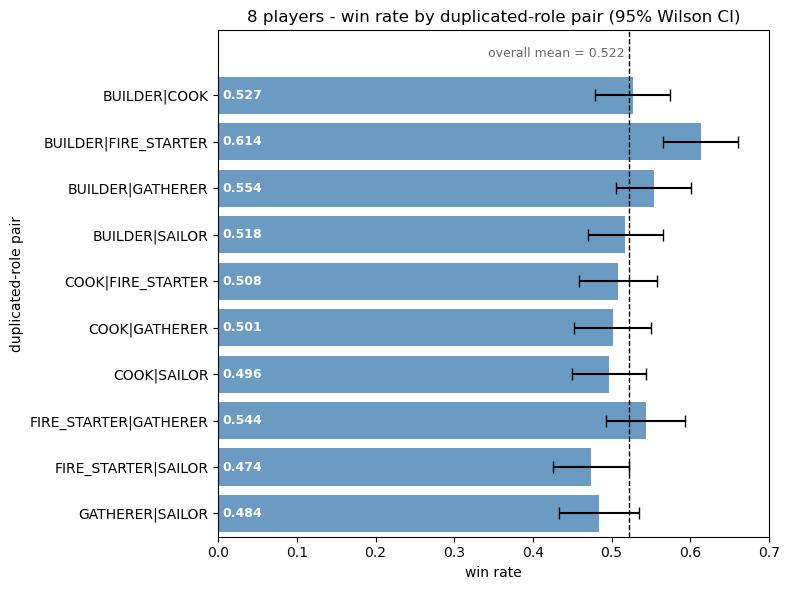

In [16]:
positions = np.arange(len(summary_8))
errors_lower = summary_8["win_rate"].values - summary_8["ci_lower"].values
errors_upper = summary_8["ci_upper"].values - summary_8["win_rate"].values
overall_win_rate_8 = contingency_8["win"].sum() / contingency_8.sum().sum()

plt.figure(figsize = (8, 6))

plt.barh(positions, summary_8["win_rate"].values, color = "steelblue", alpha = 0.8)

plt.errorbar(summary_8["win_rate"].values, positions, xerr = [errors_lower, errors_upper],
             fmt = "none", color = "black", capsize = 4)

plt.axvline(overall_win_rate_8, color = "black", linestyle = "--", linewidth = 1)
plt.text(overall_win_rate_8 - 0.005, -0.9, f"overall mean = {overall_win_rate_8:.3f}",
         va = "center", ha = "right", fontsize = 9, color = "dimgray")

plt.yticks(positions, summary_8.index)
plt.xlabel("Win rate")
plt.ylabel("Duplicated-role pair")
plt.xlim(0, summary_8["ci_upper"].max() + 0.04)
plt.ylim(-1.4, len(summary_8) - 0.5)
plt.title("Win rate by duplicated-role pair at 8 players (95% Wilson CI)")

for i, win_rate in enumerate(summary_8["win_rate"].values):
    plt.text(0.005, i, f"{win_rate:.3f}", va = "center", ha = "left",
             color = "white", fontweight = "bold", fontsize = 9)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

**Chi-square test of independence** on the (number_of_pairs x 2) table. Cochran's rule asks for every expected count to be at least 5; the printout below confirms this is met.

In [17]:
chi2_stat_8, p_value_8, dof_8, expected_8 = chi2_contingency(contingency_8.values)

print(f"chi-square statistic:  {chi2_stat_8:.4f}")
print(f"degrees of freedom:    {dof_8}")
print(f"p-value:               {p_value_8:.4e}")
print(f"min expected count:    {expected_8.min():.1f}")

chi-square statistic:  23.7858
degrees of freedom:    9
p-value:               4.6532e-03
min expected count:    175.9


**Pairwise 95% CIs on the difference in win rate** between every pair of pair-buckets, computed the same way as in the 7-player branch: for each pair the table reports the observed difference, its 95% Newcombe CI, and whether the CI excludes zero (a CI strictly above or strictly below zero means "same win rate" is outside the 95% CI and can be rejected at the 5% level).

The full table has $\binom{10}{2} = 45$ rows and is shown in the same pair-iteration order as the 7-player table.

In [18]:
pairwise_8 = pairwise_diff_table(contingency_8)
pairwise_8

,bucket_a,bucket_b,diff,ci_lower,ci_upper,excludes_zero
0,BUILDER|COOK,BUILDER|FIRE_STARTER,-0.086807,-0.153993,-0.018437,True
1,BUILDER|COOK,BUILDER|GATHERER,-0.026870,-0.094229,0.040819,False
2,BUILDER|COOK,BUILDER|SAILOR,0.009182,-0.058344,0.076575,False
3,BUILDER|COOK,COOK|FIRE_STARTER,0.019097,-0.050046,0.088002,False
4,BUILDER|COOK,COOK|GATHERER,0.025544,-0.043604,0.094362,False
5,BUILDER|COOK,COOK|SAILOR,0.030342,-0.037259,0.097544,False
6,BUILDER|COOK,FIRE_STARTER|GATHERER,-0.016706,-0.085875,0.052746,False
7,BUILDER|COOK,FIRE_STARTER|SAILOR,0.053145,-0.015702,0.121286,False
8,BUILDER|COOK,GATHERER|SAILOR,0.043134,-0.027117,0.112797,False
9,BUILDER|FIRE_STARTER,BUILDER|GATHERER,0.059937,-0.007766,0.126778,False


**Observation (8-player branch).** The chi-square rejects $H_0$ at 8 players too ($p = 4.7 \times 10^{-3}$). The pairwise CIs show the same Builder pattern at the pair level: BUILDER|FIRE_STARTER (61.4%) is the top bucket, and every BUILDER|FIRE_STARTER-vs-other comparison has a CI strictly above zero. Builder-containing pairs in general dominate the upper half of the table; the lowest two buckets (FIRE_STARTER|SAILOR 47.4% and GATHERER|SAILOR 48.4%) contain neither Builder nor each other in the rejecting set. The 7-player Builder effect therefore carries straight through to 8 players, with Fire Starter pairing producing the strongest combination.

## 2.6. Decision

The chi-square tests show that win probability is not independent of the duplicated role at either player count: $p = 1.4 \times 10^{-3}$ at 7 players and $p = 4.7 \times 10^{-3}$ at 8 players, both well below $\alpha = 0.05$. We **reject $H_0$** in favour of $H_1$ at both player counts. Both p-values enter the Holm-Bonferroni family in the main notebook under the single label **Hypothesis 2**, with the smaller of the two ($1.4 \times 10^{-3}$) reported as the H2 representative.

The pairwise CIs make the source of the effect concrete: **duplicating the Builder role yields a higher win rate than duplicating any other non-Craftsman role**.

- At 7 players, Builder duplication wins 54.5% of games; the other four roles cluster between 45.8% and 46.7%. Every BUILDER-vs-other pairwise difference CI excludes zero; no other pair does.
- At 8 players, the same pattern holds at the pair level: every pair containing Builder + Fire Starter (the highest bucket, 61.4%) sits significantly above the lowest buckets (Fire Starter|Sailor 47.4%, Gatherer|Sailor 48.4%), and Builder-containing pairs in general dominate the upper half of the chart.

This is a balance concern: the random duplication mechanic, intended to add variety at 7 and 8 players, in practice gives groups that draw Builder a measurable advantage. It should be flagged in the discussion section of the main notebook alongside the player-count effect from Hypothesis 1.

In [19]:
representative_p_value = min(p_value_7, p_value_8)

print(f"7-player chi-square p-value: {p_value_7:.4e}")
print(f"8-player chi-square p-value: {p_value_8:.4e}")
print(f"H2 representative p-value:   {representative_p_value:.4e}")

7-player chi-square p-value: 1.4277e-03
8-player chi-square p-value: 4.6532e-03
H2 representative p-value:   1.4277e-03


In [20]:
hypothesis_result = {
    "hypothesis": "H2",
    "description": "Duplication effect at 7 and 8 players",
    "test": "chi-square",
    "p_value": float(representative_p_value),
}

hypothesis_results_path.mkdir(parents = True, exist_ok = True)
with open(hypothesis_results_path / "h2.json", "w") as output_file:
    json.dump(hypothesis_result, output_file, indent = 2)

print(json.dumps(hypothesis_result, indent = 2))

{
  "hypothesis": "H2",
  "description": "Duplication effect at 7 and 8 players",
  "test": "chi-square",
  "p_value": 0.001427738620762493
}
